<a href="https://colab.research.google.com/github/olgasherbiena/KPI/blob/main/%D0%90%D0%9A%D0%9C%D0%9C%D0%9D_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Добро пожаловать в Colab!

In [1]:
!wget http://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip

--2026-05-12 19:56:53--  http://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip
Resolving press.liacs.nl (press.liacs.nl)... 132.229.137.37
Connecting to press.liacs.nl (press.liacs.nl)|132.229.137.37|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip [following]
--2026-05-12 19:56:54--  https://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip
Connecting to press.liacs.nl (press.liacs.nl)|132.229.137.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3069184257 (2.9G) [application/zip]
Saving to: ‘mirflickr25k.zip’

mirflickr25k.zip    100%[===================>]   2.86G  36.3MB/s    in 2m 48s  

2026-05-12 19:59:42 (17.5 MB/s) - ‘mirflickr25k.zip’ saved [3069184257/3069184257]



In [2]:
!unzip -q mirflickr25k.zip

In [4]:
import os, random, cv2
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- 1. Відновлення вибірки (Пункт 1) ---
base_path = "/content/mirflickr"
student_id = 12  # Ваш номер у списку
random.seed(student_id)
all_indices = list(range(1, 20001))
sample_indices = random.sample(all_indices, 250)

# Списки для векторів параметрів (Пункт 3)
vectors_a, vectors_b, vectors_c, vectors_d = [], [], [], []

print("🚀 Розрахунок параметрів для 250 зображень...")

for idx in sample_indices:
    img = cv2.imread(os.path.join(base_path, f"im{idx}.jpg"))
    if img is None: continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    means, vars_val, skews, kurts = [], [], [], []

    for j in range(3):  # Обробка каналів R, G, B (Пункт 2)
        data = img_rgb[:, :, j].flatten()
        means.append(np.mean(data))
        vars_val.append(np.var(data))
        skews.append(stats.skew(data))
        kurts.append(stats.kurtosis(data))

    # Формування векторів (Пункт 3)
    vectors_a.append(means)  # Тільки сподівання
    vectors_b.append(means + vars_val)  # Сподівання + дисперсія
    vectors_c.append(means + vars_val + skews)  # + асиметрія
    vectors_d.append(means + vars_val + skews + kurts)  # + ексцес

print(f"✅ Вектори сформовані. Приклад вектора D для першого фото:\n{vectors_d[0]}")

🚀 Розрахунок параметрів для 250 зображень...
✅ Вектори сформовані. Приклад вектора D для першого фото:
[np.float64(129.613152), np.float64(144.69461333333334), np.float64(149.59648), np.float64(2989.8832019582296), np.float64(3907.4309416504884), np.float64(5682.1381316096), np.float64(-0.7559514428937193), np.float64(-0.7958588203953325), np.float64(-0.6057631361081122), np.float64(-0.6751015594234215), np.float64(-0.836760559533432), np.float64(-1.1913839586771242)]


Середнє (Mean): Це математичне сподівання. Для пікселів (0–255) воно показує загальну яскравість каналу.

Дисперсія (Var): Другий центральний момент. Показує розкид кольорів (контрастність)

Асиметрія (Skew): Третій центральний момент. Від'ємна.
Від'ємна асиметрія означає, що лівий хвіст розподілу довший, а більша частина значень (маса) зосереджена праворуч, тобто у світлих тонах

Ексцес (Kurtosis): Четвертий центральний момент.
Це платикуртичний розподіл — він більш плоский, ніж нормальний, з менш вираженим піком

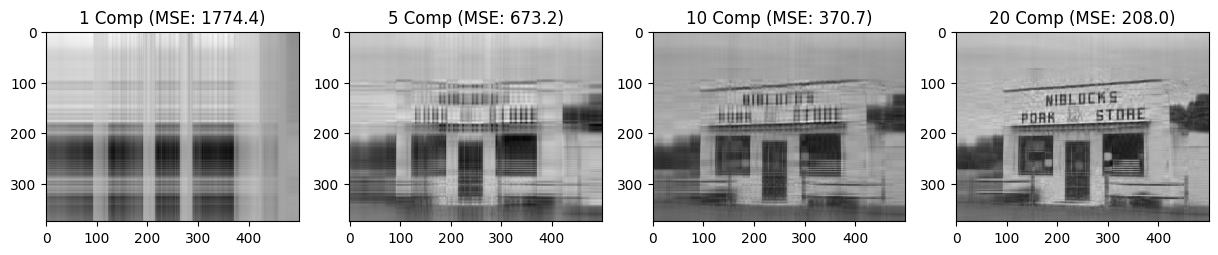

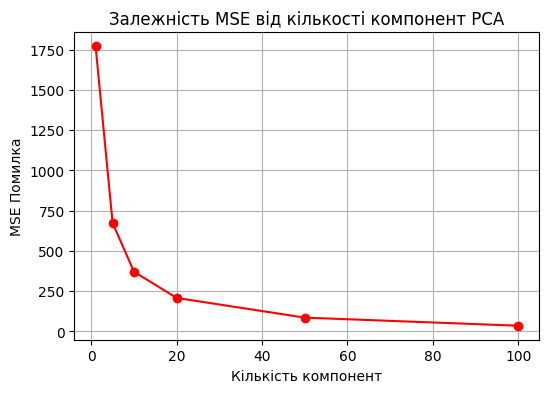

In [5]:
from sklearn.decomposition import PCA

# Беремо Червоний канал першого зображення вибірки
test_img = cv2.imread(os.path.join(base_path, f"im{sample_indices[0]}.jpg"), 0) # 0 - відразу в сірому
h, w = test_img.shape

mse_history = []
comp_list = [1, 5, 10, 20, 50, 100] # Кількість компонент для перевірки

plt.figure(figsize=(15, 5))
for i, k in enumerate(comp_list):
    pca = PCA(n_components=k)
    compressed = pca.fit_transform(test_img)
    reconstructed = pca.inverse_transform(compressed)

    mse = np.mean((test_img - reconstructed) ** 2)
    mse_history.append(mse)

    if i < 4: # Покажемо перші 4 приклади
        plt.subplot(1, 4, i+1)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"{k} Comp (MSE: {mse:.1f})")

plt.show()

# Графік залежності (Пункт 5.b)
plt.figure(figsize=(6, 4))
plt.plot(comp_list, mse_history, 'r-o')
plt.title("Залежність MSE від кількості компонент PCA")
plt.xlabel("Кількість компонент")
plt.ylabel("MSE Помилка")
plt.grid()
plt.show()

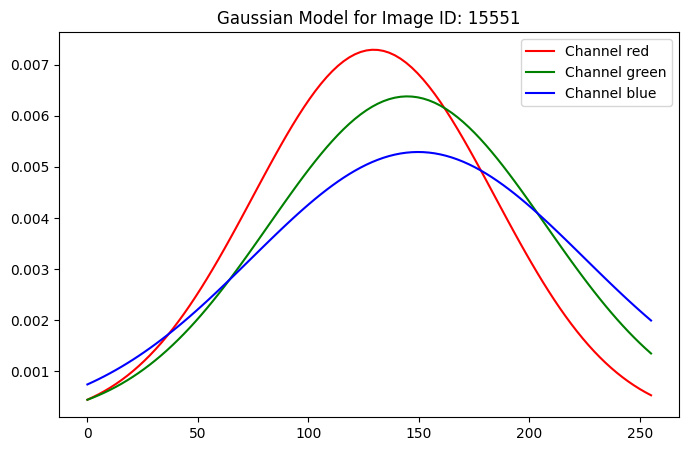

In [6]:
def plot_gaussian_model(image_idx):
    # Знаходимо дані для конкретного зображення в vectors_b (mean + var)
    # vectors_b зберігає [R_mean, G_mean, B_mean, R_var, G_var, B_var]
    idx_in_list = 0 # Візьмемо перше зі списку для прикладу
    params = vectors_b[idx_in_list]

    x = np.linspace(0, 255, 100)
    plt.figure(figsize=(8, 5))

    colors = ['red', 'green', 'blue']
    for i in range(3):
        mu = params[i]
        sigma = np.sqrt(params[i+3])
        y = stats.norm.pdf(x, mu, sigma)
        plt.plot(x, y, label=f'Channel {colors[i]}', color=colors[i])

    plt.title(f"Gaussian Model for Image ID: {sample_indices[idx_in_list]}")
    plt.legend()
    plt.show()

plot_gaussian_model(sample_indices[0])

In [7]:
def get_markov_matrix(channel_data, states=256):
    # Створюємо матрицю переходів
    matrix = np.zeros((states, states))

    # Проходимо по рядках зображення
    for row in channel_data:
        for i in range(len(row) - 1):
            curr_pixel = row[i]
            next_pixel = row[i+1]
            matrix[curr_pixel, next_pixel] += 1

    # Перетворюємо в стохастичну (сума рядка = 1)
    row_sums = matrix.sum(axis=1)
    # Уникаємо ділення на нуль
    matrix[row_sums > 0] /= row_sums[row_sums > 0, np.newaxis]
    return matrix

# Вибираємо одне тестове зображення та його канал (наприклад, Green)
test_img_path = os.path.join(base_path, f"im{sample_indices[0]}.jpg")
img_markov = cv2.imread(test_img_path)
green_channel = img_markov[:, :, 1]

P = get_markov_matrix(green_channel)

# Виводимо фрагмент матриці 10x10 для звіту
print("Фрагмент матриці переходів P (10x10):")
print(pd.DataFrame(P[:10, :10]).round(3))

Фрагмент матриці переходів P (10x10):
       0      1      2      3      4      5      6      7      8      9
0  0.185  0.073  0.053  0.079  0.013  0.046  0.033  0.007  0.007  0.020
1  0.115  0.092  0.057  0.080  0.057  0.069  0.023  0.011  0.034  0.000
2  0.188  0.087  0.087  0.058  0.043  0.043  0.029  0.029  0.029  0.000
3  0.113  0.031  0.062  0.072  0.052  0.072  0.010  0.031  0.062  0.031
4  0.075  0.075  0.045  0.090  0.000  0.075  0.030  0.030  0.015  0.015
5  0.047  0.082  0.047  0.094  0.035  0.071  0.071  0.012  0.059  0.024
6  0.031  0.000  0.020  0.061  0.020  0.010  0.041  0.071  0.061  0.082
7  0.014  0.007  0.007  0.007  0.014  0.036  0.014  0.101  0.144  0.165
8  0.003  0.006  0.008  0.008  0.014  0.014  0.011  0.080  0.172  0.258
9  0.003  0.003  0.003  0.003  0.005  0.006  0.017  0.021  0.151  0.302


In [8]:
# Підносимо матрицю до 5-го степеня
P_5 = np.linalg.matrix_power(P, 5)

# Перевірка на регулярність (чи є нулі?)
is_regular = np.all(P_5 > 0)
# Перевірка на незворотність (спрощено: чи немає ізольованих станів)
is_irreducible = np.all(np.sum(P_5, axis=0) > 0)

print(f"\nРезультати перевірки на 5 ітераціях:")
print(f"1. Регулярність: {is_regular}")
print(f"2. Незворотність: {is_irreducible}")


Результати перевірки на 5 ітераціях:
1. Регулярність: True
2. Незворотність: True


рекурентність (пункт 6.b). У марковських ланцюгах зі скінченною кількістю станів, якщо стан є незворотним (irreducible) і скінченним, то він автоматично є рекурентним. Тобто, якщо ви підтвердили irreducible, ви підтвердили і рекурентність.

In [9]:
def get_markov_1st_order(data, states=256):
    matrix = np.zeros((states, states))
    for i in range(len(data)-1):
        matrix[data[i], data[i+1]] += 1
    row_sums = matrix.sum(axis=1)
    matrix[row_sums > 0] /= row_sums[row_sums > 0, np.newaxis]
    return matrix

def get_markov_2nd_order(data, states=16):
    # Квантуємо дані до 16 рівнів для 2-го порядку
    data_q = (data // (256 // states)).astype(int)
    # Матриця станів: (попередній, поточний) -> наступний
    # Розмір (states*states) x states
    matrix = np.zeros((states*states, states))

    for i in range(len(data_q)-2):
        state = data_q[i] * states + data_q[i+1]
        next_val = data_q[i+2]
        matrix[state, next_val] += 1

    row_sums = matrix.sum(axis=1)
    matrix[row_sums > 0] /= row_sums[row_sums > 0, np.newaxis]
    return matrix

# Вибираємо канал для демонстрації
test_channel = cv2.imread(os.path.join(base_path, f"im{sample_indices[0]}.jpg"), 0)

# Напрямки (Пункт 6.a)
directions = {
    "LR": test_channel.flatten(),               # Зліва направо
    "RL": np.flip(test_channel, axis=1).flatten(), # Справа наліво
    "TB": test_channel.T.flatten(),              # Зверху вниз
    "BT": np.flip(test_channel.T, axis=1).flatten()# Знизу вверх
}

# Розрахунок для звіту (один напрямок)
P1 = get_markov_1st_order(directions["LR"])
print("✅ Матриця 1-го порядку готова.")

# Перевірка властивостей (Пункт 6.b)
def check_properties(P, steps=5):
    P_n = np.linalg.matrix_power(P, steps)
    regular = np.all(P_n > 0)
    # Перевірка на незворотність (irreducible) - чи всі стани досяжні
    irreducible = np.all(np.sum(P_n, axis=0) > 0)
    return regular, irreducible

reg, irr = check_properties(P1)
print(f"Властивості на 5 ітерації: Регулярність={reg}, Незворотність={irr}")

✅ Матриця 1-го порядку готова.
Властивості на 5 ітерації: Регулярність=True, Незворотність=True
